# Intent Classification Evaluation Notebook

**Dataset:** `intent_binary_dataset.csv`, `intent_binary_testset.csv`

**Pipeline:**
1. Load full dataset, clean data
2. Train model via `train.py`
3. Evaluate: classification_report, confusion matrix, error analysis

**Pass/Fail Thresholds:**

| Metric | Threshold |
|---|---|
| Overall Accuracy | ≥ 0.85 |
| Macro F1 | ≥ 0.85 |
| Precision (label 1) | ≥ 0.83 |
| Recall (label 1) | ≥ 0.83 |

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 1. Đọc trực tiếp 2 file đã được tách sẵn
df_train = pd.read_csv('intent_binary_dataset.csv').dropna()
df_test = pd.read_csv('intent_binary_testset.csv').dropna()

# 2. In ra các thông số
print(f'Total samples: {len(df_train) + len(df_test)}')
print(f'\nTrain size: {len(df_train)} | Test size: {len(df_test)}\n')


# 3. Lấy dữ liệu test cất vào biến để lát nữa chấm điểm
X_test = df_test['text'].tolist()
y_test = df_test['label'].astype(int).tolist()

print('Đã nạp xong dữ liệu từ 2 file! Sẵn sàng train.')

Total samples: 935

Train size: 748 | Test size: 187

Đã nạp xong dữ liệu từ 2 file! Sẵn sàng train.


## Train Model

In [2]:
!python train.py

Saved classifier + encoder models



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9940.02it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.

Batches: 100%|██████████| 24/24 [00:02<00:00,  9.52it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.21it/s]


In [3]:
encoder = SentenceTransformer('models/intent_encoder', device='cpu')

print("Đang mã hóa (encode) toàn bộ tập Train để chạy K-Fold...")
# Sử dụng df_train đã được đọc từ cell đầu tiên và encoder đã load
X_train_cv = encoder.encode(df_train['text'].tolist(), show_progress_bar=True)
y_train_cv = df_train['label'].astype(int).tolist()

# Khởi tạo mô hình trống, tham số giống hệt file train.py của bạn
clf_cv = LogisticRegression(max_iter=1000)

print("Đang chạy 10-Fold Cross Validation (K=10)...")
# Chạy đánh giá chéo 10 lần, ưu tiên đo bằng Macro F1 (giống Pass/Fail threshold của bạn)
scores = cross_val_score(clf_cv, X_train_cv, y_train_cv, cv=10, scoring='f1_macro')

print("\n" + "="*50)
print("KẾT QUẢ 10-FOLD CROSS VALIDATION TẬP TRAIN")
print("="*50)
for i, score in enumerate(scores, 1):
    print(f"  Fold {i:<2}: {score:.4f}")

print("-" * 50)
print(f"  F1-Macro Trung bình: {np.mean(scores):.4f}")
print(f"  Độ lệch chuẩn (Std): +/- {np.std(scores):.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Đang mã hóa (encode) toàn bộ tập Train để chạy K-Fold...


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Đang chạy 10-Fold Cross Validation (K=10)...

KẾT QUẢ 10-FOLD CROSS VALIDATION TẬP TRAIN
  Fold 1 : 0.9733
  Fold 2 : 1.0000
  Fold 3 : 0.9732
  Fold 4 : 0.9600
  Fold 5 : 0.9333
  Fold 6 : 0.9333
  Fold 7 : 0.9600
  Fold 8 : 0.9066
  Fold 9 : 0.8466
  Fold 10: 0.9054
--------------------------------------------------
  F1-Macro Trung bình: 0.9392
  Độ lệch chuẩn (Std): +/- 0.0421


## Evaluate on Test Set

In [ ]:
print("Đang tải mô hình và chấm điểm trên tập Test...")
clf = joblib.load('models/intent_classifier.pkl')

# 1. Dự đoán
y_pred = clf.predict(encoder.encode(X_test, show_progress_bar=True))

# 2. Báo cáo phân loại (Classification Report)
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)

# Lấy dạng dictionary để dễ dàng truy xuất các chỉ số precision, recall cho label 1 (Recommend)
report_dict = classification_report(y_test, y_pred, target_names=['0 (No Recommend)', '1 (Recommend)'], output_dict=True)
print(classification_report(y_test, y_pred, target_names=['0 (No Recommend)', '1 (Recommend)']))


# 3. PASS/FAIL SUMMARY
THRESHOLDS = {'accuracy': 0.85, 'macro_f1': 0.85, 'precision_label1': 0.83, 'recall_label1': 0.83}
acc = accuracy_score(y_test, y_pred)
mf1 = f1_score(y_test, y_pred, average='macro')
p1  = report_dict['1 (Recommend)']['precision']
r1  = report_dict['1 (Recommend)']['recall']

print('=' * 50)
print('PASS/FAIL SUMMARY')
print('=' * 50)
for name, val, thr in [
    ('Accuracy',           acc, THRESHOLDS['accuracy']),
    ('Macro F1',           mf1, THRESHOLDS['macro_f1']),
    ('Precision (label 1)', p1, THRESHOLDS['precision_label1']),
    ('Recall (label 1)',    r1, THRESHOLDS['recall_label1']),
]:
    status = 'PASS ✓' if val >= thr else 'FAIL ✗'
    print(f'  {name:<25} {val:.4f}  (threshold {thr})  [{status}]')



Đang tải mô hình và chấm điểm trên tập Test...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]


CLASSIFICATION REPORT
                  precision    recall  f1-score   support

0 (No Recommend)       0.88      0.91      0.90        94
   1 (Recommend)       0.91      0.87      0.89        93

        accuracy                           0.89       187
       macro avg       0.89      0.89      0.89       187
    weighted avg       0.89      0.89      0.89       187

PASS/FAIL SUMMARY
  Accuracy                  0.8930  (threshold 0.85)  [PASS ✓]
  Macro F1                  0.8930  (threshold 0.85)  [PASS ✓]
  Precision (label 1)       0.9101  (threshold 0.83)  [PASS ✓]
  Recall (label 1)          0.8710  (threshold 0.83)  [PASS ✓]


## Confusion Matrix

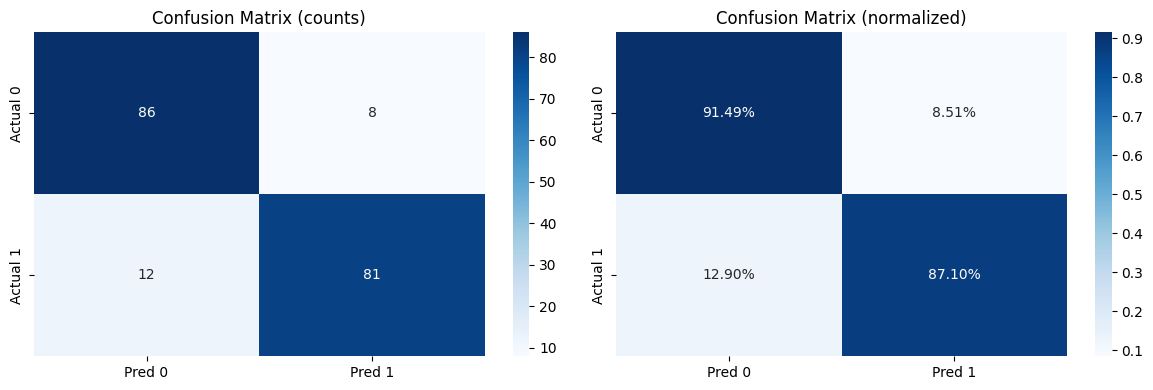

TP=81  TN=86  FP=8  FN=12
False Positive Rate: 0.0851 — gợi ý nhầm khi user chỉ hỏi thông tin
False Negative Rate: 0.1290 — bỏ sót yêu cầu gợi ý dịch vụ


In [5]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'TP={tp}  TN={tn}  FP={fp}  FN={fn}')
print(f'False Positive Rate: {fp/(fp+tn):.4f} — gợi ý nhầm khi user chỉ hỏi thông tin')
print(f'False Negative Rate: {fn/(fn+tp):.4f} — bỏ sót yêu cầu gợi ý dịch vụ')

## Error Analysis

In [6]:
errors = [(X_test[i], y_test[i], y_pred[i])
          for i in range(len(X_test)) if y_test[i] != y_pred[i]]

fp_errors = [(t, tl, pl) for t, tl, pl in errors if tl == 0 and pl == 1]
fn_errors = [(t, tl, pl) for t, tl, pl in errors if tl == 1 and pl == 0]

print(f'Total misclassified: {len(errors)} / {len(X_test)}')

print(f'\nFALSE POSITIVES ({len(fp_errors)}) — actual=0, predicted=1')
print('Model gợi ý dịch vụ trong khi user chỉ hỏi thông tin y tế:')
for idx, (text, tl, pl) in enumerate(fp_errors, 1):
    print(f'  FP{idx:02d}: [0→1] {text[:80]}')

print(f'\nFALSE NEGATIVES ({len(fn_errors)}) — actual=1, predicted=0')
print('Model bỏ sót yêu cầu gợi ý dịch vụ:')
for idx, (text, tl, pl) in enumerate(fn_errors, 1):
    print(f'  FN{idx:02d}: [1→0] {text[:80]}')

Total misclassified: 20 / 187

FALSE POSITIVES (8) — actual=0, predicted=1
Model gợi ý dịch vụ trong khi user chỉ hỏi thông tin y tế:
  FP01: [0→1] Phụ nữ mang thai có dễ bị sỏi thận không?
  FP02: [0→1] Chi phí vật lý trị liệu ở bệnh viện tư khoảng bao nhiêu?
  FP03: [0→1] Chế độ ăn cho người bị trầm cảm nên bao gồm những gì?
  FP04: [0→1] Tác dụng phụ thường gặp khi dùng thuốc trị suy giáp?
  FP05: [0→1] Chế độ ăn cho người bị viêm khớp dạng thấp nên bao gồm những gì?
  FP06: [0→1] Thời gian ủ bệnh của rối loạn tiền đình là bao lâu?
  FP07: [0→1] Người cao tuổi cần lưu ý gì khi bị gút (gout)?
  FP08: [0→1] Chế độ ăn cho người bị máu nhiễm mỡ nên bao gồm những gì?

FALSE NEGATIVES (12) — actual=1, predicted=0
Model bỏ sót yêu cầu gợi ý dịch vụ:
  FN01: [1→0] Bác sĩ Thần kinh nào mát tay ở Huế?
  FN02: [1→0] Gợi ý cho tôi bác sĩ giỏi chữa trầm cảm tại Hải Phòng.
  FN03: [1→0] Ở Biên Hòa có trung tâm phục hồi chức năng nào tốt?
  FN04: [1→0] Cần làm nail ở Cần Thơ, chỗ nảo giá cả phải c